# **SARMIMA & SARIMAX**

## **IMPORTS**

In [5]:
# Dataset import
from ucimlrepo import fetch_ucirepo

# General imports
import numpy as np
import pandas as pd 

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

## **DATASET LOADING**

In [ ]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df_original = bike_sharing.data.original

# Comprobamos que están todas
X = df_original.drop(["cnt","casual","registered"], axis = "columns")

y_casual = df_original["casual"]
y_registered = df_original["registered"]


# variable information 
print(bike_sharing.variables)

print(df_original.head())

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

In [22]:
# 1. Definir dónde damos el "hachazo" (Punto de corte). 
# Por ejemplo, usar el 80% de los datos históricos para entrenar y guardar el 20% final para test.
split_index = int(len(df_original) * 0.80)

# 2. Dividir la matriz de exógenas (X)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# 3. Dividir las variables objetivo (y) - Usuarios Casuales
y_casual_train = y_casual.iloc[:split_index]
y_casual_test = y_casual.iloc[split_index:]

# 4. Dividir las variables objetivo (y) - Usuarios Registrados
y_registered_train = y_registered.iloc[:split_index]
y_registered_test = y_registered.iloc[split_index:]

print(f"Tamaño de entrenamiento: {len(y_casual_train)} horas")
print(f"Tamaño de test: {len(y_casual_test)} horas")

Tamaño de entrenamiento: 13903 horas
Tamaño de test: 3476 horas


## **SARIMA**

We are looking for: (p, d, q) * (P, D, Q, s)

We already know that s = 24, as the main seasonality is hourly (we know this due to the analysis we made in deliverable 1)

### Check Stationary (ADF test) --> d

In [ ]:
def adf_test(y):
    ADF_result = adfuller(y)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}') #if <0.05 stationary
    print(ADF_result)

In [ ]:
print("ADF CASUAL TEST..............")
adf_test(y_casual)

print("\nADF CASUAL TEST..............")
adf_test(y_registered)

#both stationary

This means that we already have the d parameter for both time series, d = 0

### Seasonal Difference (ACF Plots) --> D

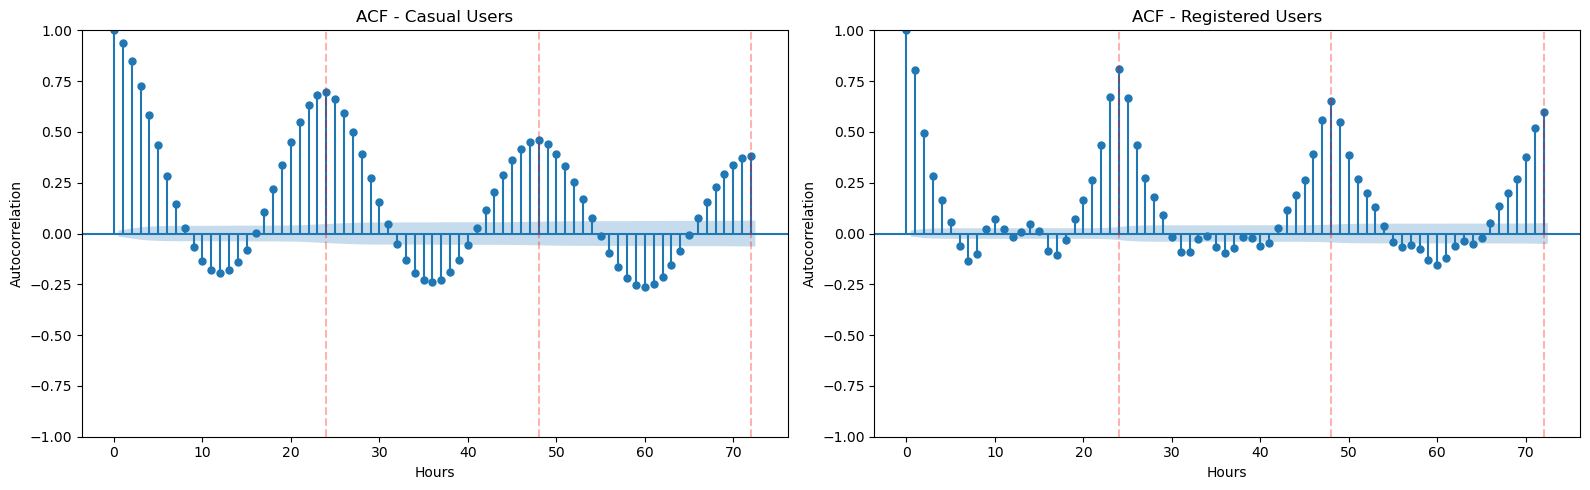

In [17]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima.arima.utils import nsdiffs

# 1 line, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Casual users (lags=72 to check 3 days)
plot_acf(y_casual, lags=72, ax=axes[0], title='ACF - Casual Users')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Autocorrelation')

# Add lines every 24 hours, which is our s
for i in range(24, 73, 24):
    axes[0].axvline(x=i, color='red', linestyle='--', alpha=0.3)

# Same for registered users
plot_acf(y_registered, lags=72, ax=axes[1], title='ACF - Registered Users')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[1].axvline(x=i, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

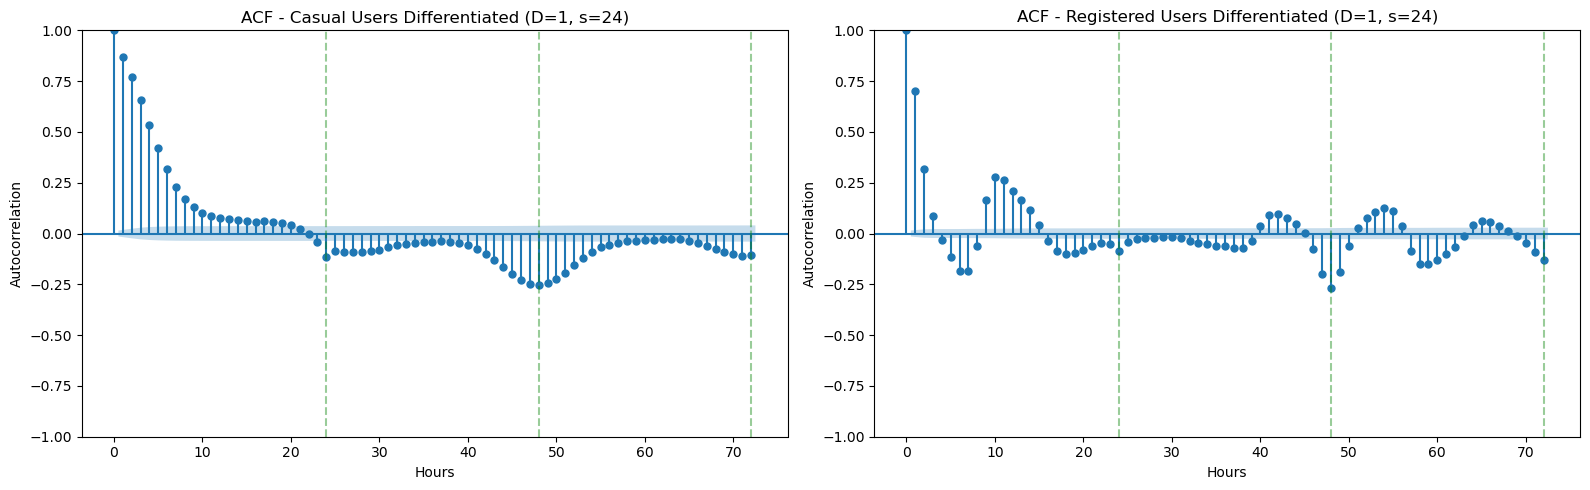

In [18]:
# Substract to each value, the value from 24 hours ago
y_casual_diff = y_casual.diff(periods=24).dropna()
y_registered_diff = y_registered.diff(periods=24).dropna()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(y_casual_diff, lags=72, ax=axes[0], title='ACF - Casual Users Differentiated (D=1, s=24)')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[0].axvline(x=i, color='green', linestyle='--', alpha=0.4) # Cambio a verde para diferenciarlo

plot_acf(y_registered_diff, lags=72, ax=axes[1], title='ACF - Registered Users Differentiated (D=1, s=24)')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Autocorrelation')
for i in range(24, 73, 24):
    axes[1].axvline(x=i, color='green', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

This means that we already have the D parameter for both time series, D = 1

### Applying AIC (Grid Search) --> p,q,P,Q

In [24]:
import pandas as pd
from typing import Union
from itertools import product
from tqdm import tqdm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# Ignorar los warnings de convergencia que son normales en el grid search
warnings.filterwarnings("ignore")

def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    """
    Optimizes the SARIMA model parameters based on the lowest Akaike Information Criterion (AIC).
    """
    results = []

    for order in tqdm(order_list, desc="Evaluando modelos"):
        try:
            model = SARIMAX(
                endog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
            
            aic = model.aic
            results.append([order, aic])
        except Exception as e:
            # Si una combinación matemática es inviable, el bucle continúa
            continue

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']

    # Ordenar por el valor AIC más bajo (el mejor modelo)
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

    return result_df

In [25]:
# Definimos los rangos. Recomendable empezar de 0 a 2 para evitar tiempos de cómputo extremos con s=24
ps = range(0, 3, 1) # [0, 1, 2]
qs = range(0, 3, 1) # [0, 1, 2]
Ps = range(0, 3, 1) # [0, 1, 2]
Qs = range(0, 3, 1) # [0, 1, 2]

# Generamos todas las combinaciones posibles
SARIMA_order_list = list(product(ps, qs, Ps, Qs))
print(f"Total de modelos a evaluar por serie: {len(SARIMA_order_list)}")

Total de modelos a evaluar por serie: 81


In [ ]:
# Parámetros estructurales que demostramos previamente
d_val = 0
D_val = 1
s_val = 24

print("Iniciando Grid Search para usuarios CASUALES...")
# Sustituye 'y_casual_train' por el nombre real de tu variable de entrenamiento
SARIMA_result_casual = optimize_SARIMA(y_casual_train, SARIMA_order_list, d_val, D_val, s_val)

print("Los 5 mejores modelos para CASUALES:")
display(SARIMA_result_casual.head())

Iniciando Grid Search para usuarios CASUALES...


In [ ]:
print("Iniciando Grid Search para usuarios REGISTRADOS...")
# Sustituye 'y_registered_train' por el nombre real de tu variable de entrenamiento
SARIMA_result_registered = optimize_SARIMA(y_registered_train, SARIMA_order_list, d_val, D_val, s_val)

print("Los 5 mejores modelos para REGISTRADOS:")
display(SARIMA_result_registered.head())

### Residual analysis

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Recupera los mejores parámetros del Grid Search para casuales
# ¡Sustituye estas variables por los números reales que ganaron en la tabla!
best_p_casual, best_q_casual = 1, 1 
best_P_casual, best_Q_casual = 1, 1 

print(f"Entrenando modelo final CASUAL con: (p={best_p_casual}, d=0, q={best_q_casual}) x (P={best_P_casual}, D=1, Q={best_Q_casual}, s=24)")

# 2. Entrenamos el modelo definitivo
model_casual_final = SARIMAX(
    y_casual_train, 
    order=(best_p_casual, 0, best_q_casual), 
    seasonal_order=(best_P_casual, 1, best_Q_casual, 24), 
    simple_differencing=False
)
fit_casual_final = model_casual_final.fit(disp=False)

# 3. Diagnóstico Cualitativo (Los 4 gráficos)
fig = fit_casual_final.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Diagnóstico de Residuos - Modelo CASUAL', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Diagnóstico Cuantitativo (Test Ljung-Box)
# Miramos hasta el lag 24 porque ese es nuestro ciclo diario
residuals_casual = fit_casual_final.resid

# El dropna() es importante porque al aplicar D=1 perdemos los primeros 24 residuos
lb_test_casual = acorr_ljungbox(residuals_casual.dropna(), lags=[12, 24])
print("\n--- Test Ljung-Box (Casuales) ---")
print("H0: Los residuos son ruido blanco (independientes).")
print("Si p-value > 0.05, el modelo es BUENO (no quedan patrones).")
display(lb_test_casual)

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Recupera los mejores parámetros del Grid Search para casuales
# ¡Sustituye estas variables por los números reales que ganaron en la tabla!
best_p_registered, best_q_registered = 1, 1 
best_P_registered, best_Q_registered = 1, 1 

print(f"Entrenando modelo final CASUAL con: (p={best_p_registered}, d=0, q={best_q_registered}) x (P={best_P_registered}, D=1, Q={best_Q_registered}, s=24)")

# 2. Entrenamos el modelo definitivo
model_registered_final = SARIMAX(
    y_registered_train, 
    order=(best_p_registered, 0, best_q_registered), 
    seasonal_order=(best_P_registered, 1, best_Q_registered, 24), 
    simple_differencing=False
)
fit_registered_final = model_registered_final.fit(disp=False)

# 3. Diagnóstico Cualitativo (Los 4 gráficos)
fig = fit_registered_final.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Diagnóstico de Residuos - Modelo CASUAL', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Diagnóstico Cuantitativo (Test Ljung-Box)
# Miramos hasta el lag 24 porque ese es nuestro ciclo diario
residuals_registered = fit_registered_final.resid

# El dropna() es importante porque al aplicar D=1 perdemos los primeros 24 residuos
lb_test_registered = acorr_ljungbox(residuals_registered.dropna(), lags=[12, 24])
print("\n--- Test Ljung-Box (Registered) ---")
print("H0: Los residuos son ruido blanco (independientes).")
print("Si p-value > 0.05, el modelo es BUENO (no quedan patrones).")
display(lb_test_registered)